Missing Value Imputation - Baruni 


===== Missing Value Report =====
        missing_count  missing_pct
V6                  1       0.0012
V12                 1       0.0012
V11                 1       0.0012
V10                 1       0.0012
V9                  1       0.0012
V8                  1       0.0012
V7                  1       0.0012
V13                 1       0.0012
V14                 1       0.0012
V20                 1       0.0012
V19                 1       0.0012
V18                 1       0.0012
V17                 1       0.0012
V16                 1       0.0012
V15                 1       0.0012
V23                 1       0.0012
V24                 1       0.0012
V25                 1       0.0012
V26                 1       0.0012
V27                 1       0.0012
V28                 1       0.0012
V21                 1       0.0012
V22                 1       0.0012
Amount              1       0.0012
Class               1       0.0012
V2                  0       0.0000
V3                  0

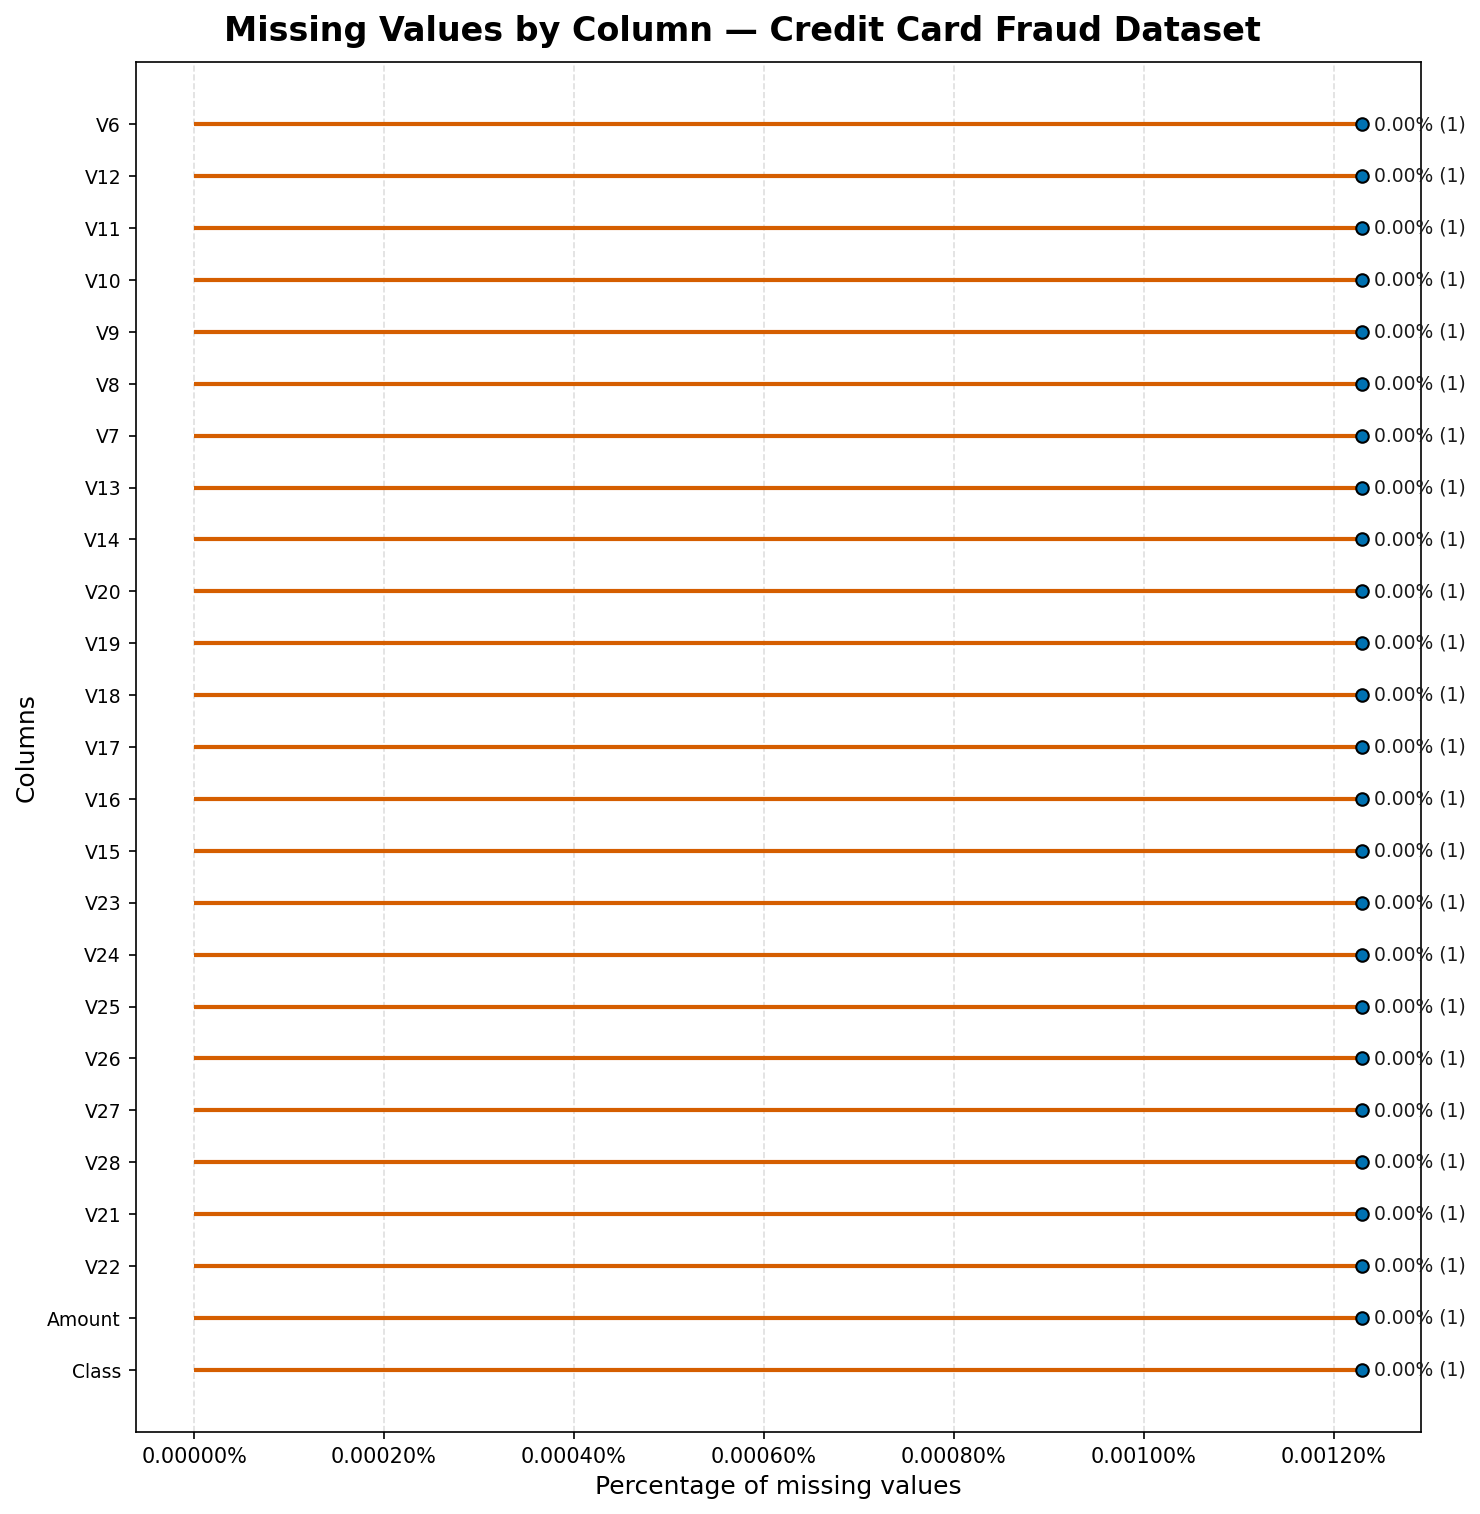

Total Missing Values:  25


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def plot_missing_values(df: pd.DataFrame, title_suffix: str = ""):
    """
    Visualize missing values by column with accessible design choices.
    - Prints a summary table.
    - Chooses bar or lollipop chart depending on number of columns with missing data.
    """

    # Compute missing counts and percentages
    missing_count = df.isnull().sum()
    missing_pct = (df.isnull().mean() * 100)

    report = pd.DataFrame({
        "missing_count": missing_count,
        "missing_pct": missing_pct
    }).sort_values("missing_pct", ascending=False)

    # Print a compact textual summary as a screen-reader-friendly fallback
    print("\n===== Missing Value Report =====")
    print(report.to_string(float_format=lambda x: f"{x:0.4f}"))

    # If no columns have missing values, create a simple, accessible “all good” figure
    if (report["missing_count"] == 0).all():
        fig, ax = plt.subplots(figsize=(6, 2.5), dpi=150)
        # [A11Y] High-contrast text with large font
        ax.text(
            0.5, 0.5,
            "No missing values detected",
            ha="center", va="center",
            fontsize=14, fontweight="bold", color="#1A1A1A"  # [A11Y] High contrast
        )
        ax.set_axis_off()
        fig.suptitle(
            f"Missing Values Summary{(' — ' + title_suffix) if title_suffix else ''}",
            fontsize=16, fontweight="bold"
        )  # [A11Y] Clear, descriptive title
        plt.tight_layout()
        plt.show()
        return report

    # Keep only columns with missing values
    plot_df = report[report["missing_count"] > 0].copy()

    # Choose chart type based on number of columns to keep labels readable
    n = len(plot_df)
    use_lollipop = n > 20  # lollipop scales better for long lists

    # [A11Y] Use Okabe-Ito colorblind-safe palette; pick two high-contrast colors
    color_bar = "#0072B2"   # blue
    color_edge = "#000000"  # black edge for contrast
    color_stem = "#D55E00"  # orange for lollipop stems

    # Dynamic figure height for readability
    fig_height = max(3.5, min(0.35 * n + 1.5, 18))
    fig, ax = plt.subplots(figsize=(10, fig_height), dpi=150)

    if not use_lollipop:
        # Horizontal bar chart (best for comparative magnitudes w/ labels)
        y = np.arange(n)
        values = plot_df["missing_pct"].values
        labels = plot_df.index.astype(str).tolist()

        bars = ax.barh(
            y, values,
            color=color_bar,
            edgecolor=color_edge, linewidth=0.8,
            # [A11Y] Hatching ensures information is legible even without color perception
            hatch="///"
        )  # [A11Y]

        ax.set_yticks(y, labels, fontsize=10)  # [A11Y] Legible tick labels
        ax.invert_yaxis()  # largest on top

        # [A11Y] Annotate values so users don’t need to rely on decoding axis
        for i, (bar, pct, cnt) in enumerate(zip(bars, plot_df["missing_pct"], plot_df["missing_count"])):
            ax.text(
                bar.get_width() + max(values) * 0.01,  # small offset to the right
                bar.get_y() + bar.get_height() / 2,
                f"{pct:0.2f}% ({int(cnt)})",
                va="center",
                fontsize=9,
                color="#1A1A1A"  # high contrast text
            )  # [A11Y]

    else:
        # Lollipop chart for many columns (cleaner labeling)
        y = np.arange(n)
        values = plot_df["missing_pct"].values
        labels = plot_df.index.astype(str).tolist()

        # [A11Y] Stems with strong contrast
        ax.hlines(y=y, xmin=0, xmax=values, color=color_stem, linewidth=2)
        ax.plot(values, y, "o", color=color_bar, markeredgecolor=color_edge)  # [A11Y] Edge for contrast

        ax.set_yticks(y, labels, fontsize=9)  # [A11Y] Legible tick labels
        ax.invert_yaxis()

        # [A11Y] Annotate numeric values
        for yi, (pct, cnt) in enumerate(zip(plot_df["missing_pct"], plot_df["missing_count"])):
            ax.text(
                pct + max(values) * 0.01,
                yi,
                f"{pct:0.2f}% ({int(cnt)})",
                va="center",
                fontsize=9,
                color="#1A1A1A"
            )  # [A11Y]

    # X-axis as percentage with gridlines
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.grid(axis="x", linestyle="--", alpha=0.4)  # [A11Y] Grid improves readability

    # [A11Y] Clear, descriptive titles and labels; large font sizes
    ax.set_xlabel("Percentage of missing values", fontsize=12)  # [A11Y]
    ax.set_ylabel("Columns", fontsize=12)                      # [A11Y]
    fig.suptitle(
        f"Missing Values by Column{(' — ' + title_suffix) if title_suffix else ''}",
        fontsize=16, fontweight="bold"
    )  # [A11Y]

    # [A11Y] Ensure sufficient contrast and space for annotations
    plt.tight_layout()
    plt.show()
   
    return report


df = pd.read_csv("zip://DS-Finance1/data/creditcard.csv.zip!creditcard.csv")
plot_missing_values(df, title_suffix="Credit Card Fraud Dataset")
print("Total Missing Values: ", df.isna().sum().sum())  # should print total missing count